# Freight Rate Assesment
**Objective**: Generate a prediction for "predict_rate" for unseen loads using historical data using a Machine Learning model

## Unit of Analysis

Based on the provided dataset, **each row represents a single freight load (`load_id`) posted on a specific date**, along with its shipment characteristics and the corresponding freight rate (`posted_rate`). The variables are interpreted as follows:

| Variable | Description |
|----------|-------------|
| **load_id** | Unique identifier for each freight load. |
| **pickup** | City where the shipment originates. |
| **delivery** | Destination city for the shipment. |
| **pickup_lat / pickup_lon** | Latitude and longitude of the pickup location. |
| **delivery_lat / delivery_lon** | Latitude and longitude of the delivery location. |
| **distance** | Distance between the pickup and delivery locations. |
| **equipment** | Type of equipment or trailer required to transport the load (e.g., Dry Van, Reefer, Flatbed). |
| **weight** | Weight of the shipment. |
| **date** | Date on which the load was posted. |
| **market_index** | Numerical indicator representing overall freight market conditions at the time the load was posted. |
| **quote_signal** | Numerical pricing-related signal associated with the load. The exact definition is not provided, but it is expected to contain predictive information about the freight rate. |
| **posted_rate** | Observed freight rate (price) for transporting the load. This is the target variable to be predicted. |

In summary, the **unit of analysis** is a **single freight load**, uniquely identified by `load_id`, with features describing the shipment and a target variable (`posted_rate`) representing the freight cost.


## Loading Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

train_data = pd.read_csv('data/train_test.csv')
validation_data = pd.read_csv('data/validation.csv')

print(f"Train data shape: {train_data.shape}")
print(f"Validation data shape: {validation_data.shape}")

# Data inspection
print("\n  Train Data Insights:")
train_data.info()
train_data.describe(include='all')
train_data.head()

print("\n Validation Data Insights:")
validation_data.info()
validation_data.describe(include='all')
validation_data.head()

print("\nChecking for negative values in train data:")
cols = ["distance", "weight", "market_index", "quote_signal", "posted_rate"]

(train_data[cols] < 0).sum()


Train data shape: (48000, 14)
Validation data shape: (12000, 13)

  Train Data Insights:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB

 Validation Data Insights:
<class 'pandas.core.frame.DataFram

distance          0
weight          292
market_index      0
quote_signal      0
posted_rate       0
dtype: int64

## Important Observations
From the train-test.csv , the 'date' column is stored as an char object and should be converted to a datetime format, the same issue is present in validation.csv.

Two variables, `weight` and `market_index` have missing values in the 48000 entries, more specifically 674 entries are missing this values, even though is less than 1% of the the total observations, still should be fixed, the same values are missing in the validation.csv.

Another issue was found in the `weight` feature where there are negative values,an aspect that is nonsensicial in freight logistics, therfore that is an issue to resolve as well.

There are cities in validation.csv that are not seen in traning: Allentown, Chicago, Charlotte, Norfolk, Knoxville, Jackson , San Diego and Laredo, therefore the pickup/delivery variables should not be taken as primary signals but rather the distance in between the cities.

## Data cleaning


The new (`train_clean`) will be the clean copy of the raw training dataset that will be used **only** for the EDA analysis
1. Removed the observartions with **missing values**
2. Remove observations with **negative** weights
3. Changed the `date` to a datetime type variable

In [2]:
# Missing values per column
print(train_data.isna().sum())

# Rows with any missing value
missing_rows = train_data.isna().any(axis=1).sum()
print(f"Rows with at least one missing value: {missing_rows}")

# Rows with negative weight
negative_weight = (train_data["weight"] < 0).sum()
print(f"Rows with negative weight: {negative_weight}")

# Create cleaned dataset
train_clean = (
    train_data
    .dropna()
    .query("weight >= 0")
    .copy()
)

# Convert the date column to datetime
train_clean["date"] = pd.to_datetime(train_clean["date"])

# Summary
print(f"Original shape: {train_data.shape}")
print(f"Cleaned shape: {train_clean.shape}")
print(f"Rows dropped: {len(train_data) - len(train_clean)}")

# Verify the conversion
print(train_clean["date"].dtype)

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64
Rows with at least one missing value: 673
Rows with negative weight: 292
Original shape: (48000, 14)
Cleaned shape: (47038, 14)
Rows dropped: 962
datetime64[ns]


## Exploratory Data Analysis (EDA)


#### Analysis of `posted_rate` 


In [3]:
train_clean["posted_rate"].describe()

count    47038.000000
mean      2373.882209
std       1486.568726
min         57.220000
25%       1251.630000
50%       2030.670000
75%       3331.117500
max      25533.000000
Name: posted_rate, dtype: float64

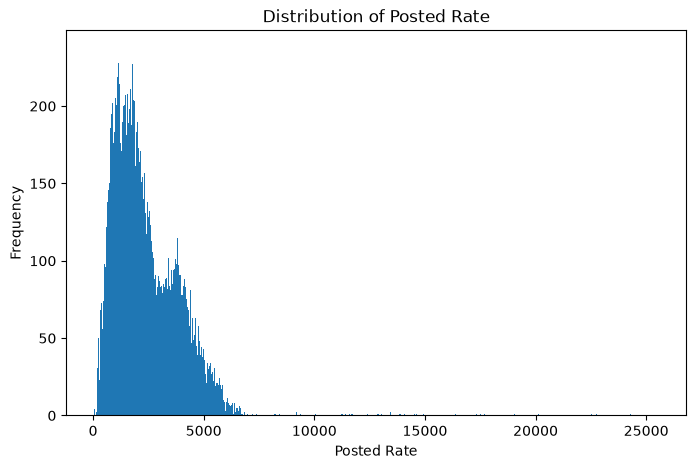

In [4]:

plt.figure(figsize=(8,5))
plt.hist(train_clean["posted_rate"], bins=2000)
plt.title("Distribution of Posted Rate")
plt.xlabel("Posted Rate")
plt.ylabel("Frequency")
plt.show()

The feature shows us that the majority of freight prices are in the `0 to 5000`range. By using the previous command we also know that the after the 0 to 5000 bracket there are outlier prices going through the `10000 to 25000` bracket, where 25000 is the highest price recorded in the dataset. This aspect gives the variable the right-skewed distribution shape. In the distribuition there are two main frequency peaks, around the `1,000 and 3,000` and a second peak on the `3,500 to 4,500` suggesting two underlying groups of freight prices

#### Relationship with **Numerical variables**

Correlation Matrix

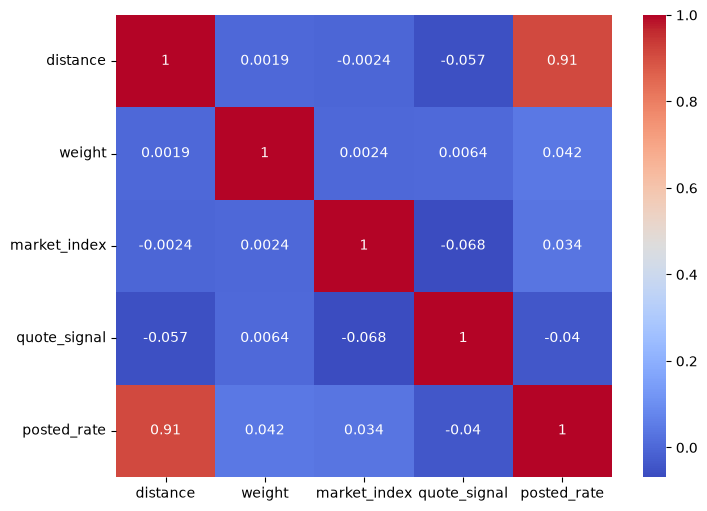

In [5]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    train_clean[
        ["distance","weight","market_index",
         "quote_signal","posted_rate"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

The **correlation matrix** describes that distance has the strongest linear relationship with the rate price, with a Pearson correlation coefficent of 0.91 we can safely say that the longer the shipments are the higher the rate will tend to go. Variables like `'weight'`, `market_index`, and `'quote_signal'` show little signs of linear correlation, although a non-linear correlation made with more sophisticated models could still be affecting the rates. Correlation does not indicate **causation**. From this correlation analysis is safe to use the distance as one of our main signals for the ML model.

#### Relationship with **Categorical Variables**

Relationship with the equipment being used to transport the load

In [6]:
train_clean["equipment"].value_counts()

equipment
Dry Van    26672
Reefer     11809
Flatbed     8557
Name: count, dtype: int64

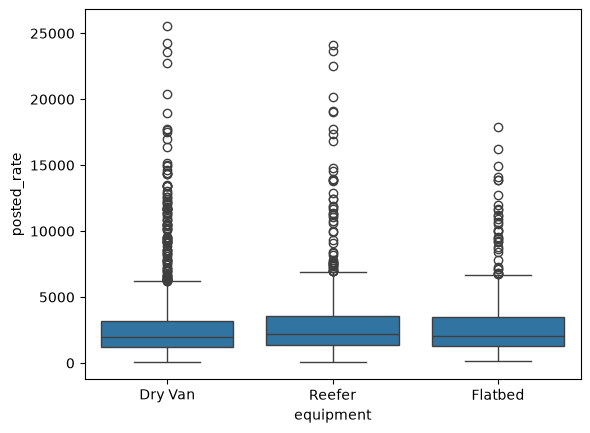

In [7]:
sns.boxplot(
    data=train_clean,
    x="equipment",
    y="posted_rate"
)
plt.show()

The boxplot tells us that despite the outlliers, the reefer equipment has the highest median posted rate in comparsion with the flatbed and dry van equipment but said difference is relatively small. The outliers indicate that there are other factors, not represented in the equipment type, that may induce the change in rates where dry vans and reefers are used in the highest reported rates whereas the outliers of flatbeds are the lowest rated among the outlier values beyond the 5000 rate in comparison to the other two equipments.

Relationship with **pickup and delivery cities**

In [8]:
train_clean["pickup"].value_counts().head(20)

pickup
Oklahoma City    1219
Lexington        1188
Bakersfield      1167
Fort Wayne       1145
Hartford         1129
Richmond         1109
Nashville        1104
Phoenix          1102
Baton Rouge      1086
Mobile           1073
Cincinnati       1058
Shreveport       1034
Kansas City      1032
Columbia         1032
Atlanta          1010
San Antonio       956
Tucson            932
Los Angeles       927
Philadelphia      925
Milwaukee         923
Name: count, dtype: int64

In [9]:
lane_stats = (
    train_data
    .groupby(["pickup", "delivery"])
    .agg(
        shipments=("posted_rate", "count"),
        avg_rate=("posted_rate", "mean"),
        avg_market_index=("market_index", "mean")
    )
    .reset_index()
)

lane_stats = lane_stats.sort_values("shipments", ascending=False)
lane_stats.head(10)


,pickup,delivery,shipments,avg_rate,avg_market_index
923,Columbia,Oklahoma City,39,2330.734615,1.084060
3002,Phoenix,Shreveport,39,3507.618462,1.130298
2007,Lexington,Atlanta,39,560.106154,1.134051
1299,Fort Wayne,Philadelphia,38,1681.032632,1.117027
3538,Shreveport,Hartford,37,2867.768108,1.044042
1279,Fort Wayne,Hartford,37,1938.657297,1.052025
3244,Richmond,Oklahoma City,37,3093.435946,1.094949
3246,Richmond,Phoenix,37,5190.194595,1.107940
2034,Lexington,Kansas City,37,1042.474595,1.076781
2017,Lexington,Cincinnati,37,396.691892,1.118951


The busiest freight lanes, identified by the number of posted shipments may not exibit a consistent relationship with the prevalence of a certian destination or delivery zone, so perhaps our best option for relating the posted rate is with the actual distance covered in between the pickup and delivery city.

Relationship with **date**

In [10]:
train_clean["month"] = train_clean["date"].dt.month

train_clean.groupby("month")["posted_rate"].mean()

month
1     2258.385657
2     2273.232855
3     2372.833940
4     2373.498963
5     2419.615031
6     2496.525469
7     2415.655160
8     2337.097114
9     2406.753913
10    2377.284790
Name: posted_rate, dtype: float64

By analyzing the posted rate by month, we can see gradual increase from January to June with a slight decline after the month of June. Throughout the year it varies from aproxximately 2,260 and 2,500 without any evident seasonal pattern. June has the highest posted rate while August has the lowest.

# ML Pipeline
It uses `src/` where there are these files: \
\
`features.py`: This file cleans the features and ceates adjustments for the dates for a cyclical realistic approach, this file does not drop any rows or delete data for the validation and december charts. It converts the raw CSV columns to the feature matrix. \

`split.py`: This file split the data in a Train Section: Jan-Aug and a Holdout Sep-Oct. This split prevent data leakeage on to future months and rates. The holdout is a way to test the model and assure that the ML model can extrapolate further to the months of interest **Nov/Dec**. \

`generate_predictions`: This file uses the sklearn ML library to run a linear regression which is optimal for predicting continuous numerical values, it uses the prepared features made with the previous scripts.




### Imports


In [11]:
import sys
import subprocess
sys.path.append("src")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from IPython.display import Image
from features import fit_clean_stats, prepare, FEATURE_COLUMNS
from split import time_split

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

### Modeling: Time-Based Split


#### Loading Raw Data

In [12]:
train_full = pd.read_csv("data/train_test.csv")
validation_data = pd.read_csv("data/validation.csv")
december_inputs = pd.read_csv("data/december_chart_inputs.csv")
predictions_template = pd.read_csv("data/validation_predictions_template.csv")

The split will be made to simulate the **Nov/Dec** forecasting scenario where the rates will be predicted

In [13]:
# Train: Jan-Aug 2025, Holdout: Sep-Oct 2025
tr_raw, va_raw = time_split(train_full)
print(f"train: {len(tr_raw)} rows ({tr_raw['date'].min()} to {tr_raw['date'].max()})")
print(f"holdout: {len(va_raw)} rows ({va_raw['date'].min()} to {va_raw['date'].max()})")

train: 38477 rows (2025-01-01 to 2025-08-31)
holdout: 9523 rows (2025-09-01 to 2025-10-31)


### Feature Engineering 

By the EDA anaylsis, the variables to be considered in the model where: `distance`, `weight`, `market_index`, `quote_signal` and a modification of the `date` where a cyclical enconding was added, from the cateoogrical variables, the type of `equipment` was taken into account.

In [14]:
# stats (medians for weight/market_index/quote_signal) are fit on the
# train split only, then reused identically on the holdout / validation /
# december data to avoid leaking information across the split
stats = fit_clean_stats(tr_raw)

X_train = prepare(tr_raw, stats)
y_train = tr_raw["posted_rate"].values

X_holdout = prepare(va_raw, stats)
y_holdout = va_raw["posted_rate"].values

X_train.head()

,distance,weight,market_index,quote_signal,days_since_start,doy_sin,doy_cos,dow_sin,dow_cos,equip_Dry Van,equip_Flatbed,equip_Reefer
0,274.3,30658.0,0.95684,2.39595,0,0.017202,0.999852,0.974928,-0.222521,True,False,False
1,280.5,17555.0,0.97623,2.43355,0,0.017202,0.999852,0.974928,-0.222521,False,False,True
2,967.8,31721.0,1.00971,1.84491,0,0.017202,0.999852,0.974928,-0.222521,True,False,False
3,965.4,32333.0,0.94518,1.87712,0,0.017202,0.999852,0.974928,-0.222521,True,False,False
4,541.9,35183.0,0.98480,2.56300,0,0.017202,0.999852,0.974928,-0.222521,False,False,True


### Model Comparison: `Linear Regression` vs. `Gradient Boosting`

Comparison of the Sept-Oct holdout:

In [15]:


models = {
    "LinearRegression": LinearRegression(),
    "GradientBoosting": HistGradientBoostingRegressor(
        max_depth=6, learning_rate=0.05, max_iter=400, random_state=42
    ),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_holdout)
    results[name] = {
        "MAE": mean_absolute_error(y_holdout, preds),
        "MAPE": mean_absolute_percentage_error(y_holdout, preds),
        "R2": r2_score(y_holdout, preds),
    }

pd.DataFrame(results).T

,MAE,MAPE,R2
LinearRegression,167.552622,0.090555,0.820427
GradientBoosting,130.398585,0.060028,0.826031


We can see that GBM has better metrics than those of linear regression where GBM has a higher determination coefficient and closer predicitions to the actual values. Despite this fact the model that will be used is linear regression since GBM methods cannot extraploate around the cyclical doy_sin and doy_cos past the traning range, linear regression however extrapolates better the December curve

### Final fit and Prediction 

Refit labeled data (Jan-Oct) and predict validation.csv

In [16]:
# Refit stats + model on the FULL labeled dataset now that model selection is done
final_stats = fit_clean_stats(train_full)
X_full = prepare(train_full, final_stats)
y_full = train_full["posted_rate"].values

final_model = LinearRegression()
final_model.fit(X_full, y_full)

X_val = prepare(validation_data, final_stats)
val_preds = final_model.predict(X_val)

submission = predictions_template.copy()
pred_map = dict(zip(validation_data["load_id"], val_preds))
submission["predicted_rate"] = submission["load_id"].map(pred_map)

assert submission["predicted_rate"].isna().sum() == 0
n_bad = (submission["predicted_rate"] <= 0).sum()
if n_bad:
    print(f"WARNING: clipping {n_bad} non-positive predictions to $1")
    submission["predicted_rate"] = submission["predicted_rate"].clip(lower=1.0)

submission.to_csv("validation_predictions.csv", index=False)
submission.describe()

,predicted_rate
count,12000.000000
mean,2435.528155
std,1367.518084
min,232.846457
25%,1347.309133
50%,2091.351369
75%,3393.282624
max,6610.875842


Predict December charts

In [17]:
X_dec = prepare(december_inputs, final_stats)
dec_preds = final_model.predict(X_dec)

december_filled = december_inputs.copy()
december_filled["predicted_rate"] = dec_preds
december_filled.to_csv("data/december_chart_inputs.csv", index=False)

december_filled[["date", "predicted_rate"]]

,date,predicted_rate
0,2025-12-01,950.347390
1,2025-12-02,947.943242
2,2025-12-03,938.150755
3,2025-12-04,928.731810
4,2025-12-05,927.164206
5,2025-12-06,935.010731
6,2025-12-07,946.742360
7,2025-12-08,953.901733
8,2025-12-09,951.471727
9,2025-12-10,941.653464


Run the Scorer

In [18]:
result = subprocess.run(
    ["python", "score.py",
     "--predictions", "validation_predictions.csv",
     "--december-predictions", "data/december_chart_inputs.csv"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.




Prediction Chart

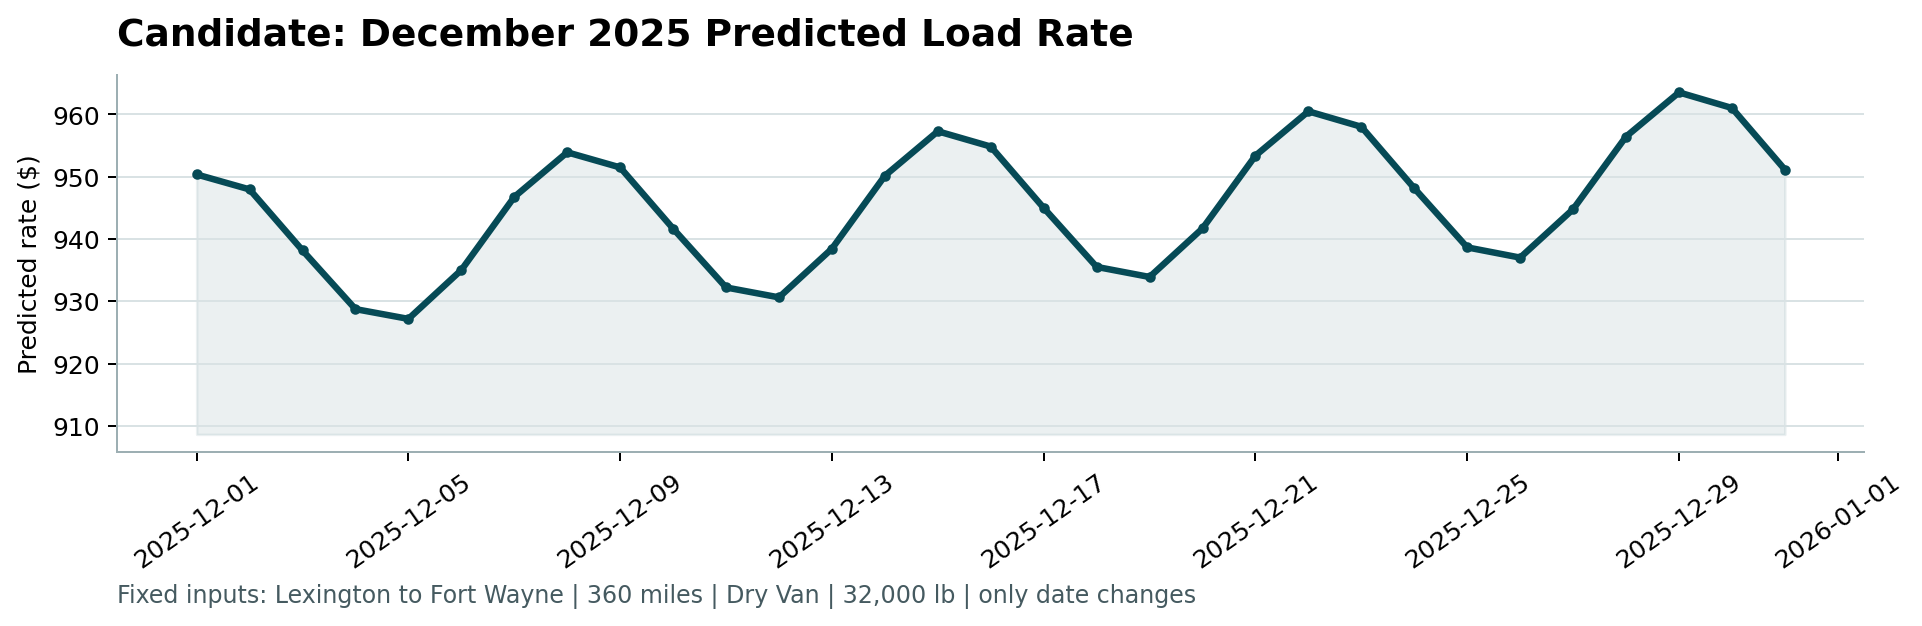

In [19]:
Image("scorer_results/candidate_december.png")